<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/263150_Hernandez_Laboratorio_1_Tema_2_Suavizado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad semanal — Tema 2
## Del dato observado al pronóstico con SMA, WMA y EMA

**Asignatura:** Métodos para Pronóstico y Analítica Avanzada  
**Modalidad:** laboratorio guiado en Google Colab  
**Caso:** una oficina de atención ciudadana registra cuántas solicitudes recibe cada semana y necesita anticipar su carga de trabajo.  

**Propósito:** aprender a leer una serie temporal, distinguir una curva suavizada de un pronóstico y comparar SMA, WMA y EMA mediante cálculos, gráficas y métricas.

### Ruta de trabajo

1. Comprender el caso y observar los datos sin aplicar métodos.
2. Calcular valores suavizados: aquí sí se conoce el dato de la semana actual.
3. Convertir esos cálculos en pronósticos: la semana que se desea predecir todavía no se conoce.
4. Comparar métodos en las mismas semanas.
5. Comprobar que la estructura de la serie influye en el método más conveniente.

Ejecute las celdas en orden, lea cada explicación y escriba sus respuestas dentro del notebook. No necesita utilizar datos de su proyecto personal.


* Asignatura: Métodos para Pronóstico y Analítica Avanzada
* Profesor: Mtro. César Alonso Rivas Flores
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* Fecha de entrega: 24 de agosto de 2026




## 1. Preparación del entorno

Usaremos `numpy` para algunos cálculos, `pandas` para organizar los datos y `matplotlib` para construir las gráficas.

El código está completo. El objetivo no es memorizar instrucciones de Python, sino relacionar cada resultado con la idea estadística que representa.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda value: f"{value:.3f}")
plt.style.use("seaborn-v0_8-whitegrid")

## 2. El caso: solicitudes ciudadanas por semana

Durante doce semanas, una oficina registró el número de solicitudes recibidas. La administración quiere responder dos preguntas distintas:

- **Descripción:** ¿cuál es la dirección general de la demanda, más allá de las subidas y bajadas semanales?
- **Pronóstico:** ¿cuántas solicitudes podrían esperarse la semana siguiente para organizar al personal?

Antes de calcular un promedio, debemos mirar la serie original. Una gráfica no es solo una figura: representa una historia que ocurre en orden temporal.


,Solicitudes observadas
Semana,
1,40
2,44
3,46
4,52
5,48
6,56
7,60
8,58
9,64


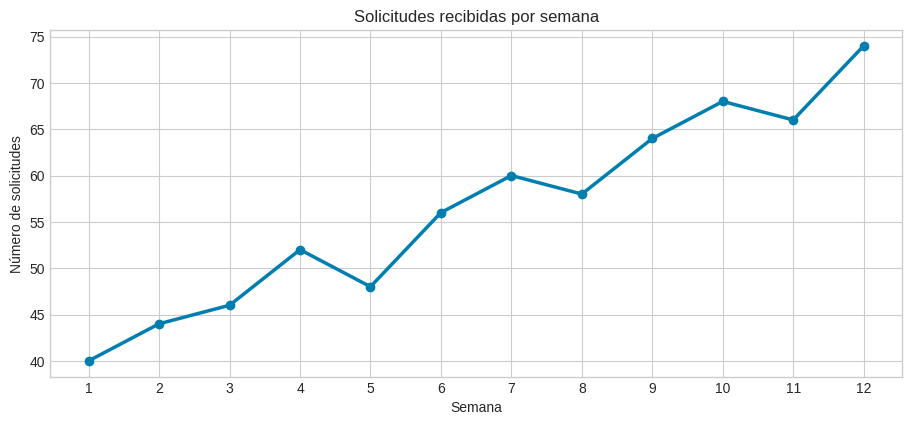

In [ ]:
datos = [40, 44, 46, 52, 48, 56, 60, 58, 64, 68, 66, 74]

serie = pd.Series(datos, index=np.arange(1, len(datos) + 1), name="Solicitudes observadas")
serie.index.name = "Semana"
display(serie.to_frame())

ax = serie.plot(figsize=(11, 4.5), marker="o", linewidth=2.5, color="#007FAF")
ax.set(title="Solicitudes recibidas por semana", xlabel="Semana", ylabel="Número de solicitudes")
ax.set_xticks(serie.index)
plt.show()


### Pregunta 1. Leer antes de calcular

1. ¿La cantidad de solicitudes permanece alrededor de un mismo nivel o muestra una dirección general?
2. Mencione dos semanas en las que la serie cambió en sentido contrario a esa dirección.
3. ¿Los doce datos bastan para afirmar que existe un patrón estacional? Justifique brevemente.

**Respuesta:**  
1. La dirección general de las solicitudes aumenta ya que se aprecia que la línea de la gráfica sube a pesar de sus fluctuaciones.
2. En la semana 5 (de 52 a 48) y en la semana 8 (de 60 a 58) bajó, a pesar del movimiento general hacia arriba.
3. Considero que no se observa un patrón estacional claro. El movimiento muestra 3 subidas-1 bajada, 2 subidas-1 bajada, 2 subidas-1 bajada y 1 subida. A pesar de que es un poco parecido, no creo que se pueda utilizar para realizar un pronóstico.


## 3. Tres maneras de resumir el pasado

Aplicaremos los tres métodos con parámetros sencillos:

- **SMA con $k=3$:** cada valor es el promedio de tres semanas y todas tienen la misma importancia.
- **WMA con pesos $[0.2, 0.3, 0.5]$:** también usa tres semanas, pero da mayor importancia a la más reciente. Los pesos se escriben de la semana más antigua a la más reciente.
- **EMA con $\alpha=0.3$:** combina el dato actual con el nivel suavizado anterior. Un $\alpha$ pequeño conserva más memoria; uno grande reacciona más al dato reciente.

Estos parámetros no son universales. Por ahora los fijaremos para observar con claridad cómo cambia el comportamiento de cada método.


In [ ]:
k = 3
pesos = np.array([0.2, 0.3, 0.5])
alpha = 0.3

print("Suma de los pesos WMA:", pesos.sum())

Suma de los pesos WMA: 1.0


## 4. Primero: suavizar la serie

Un **valor suavizado de la semana $t$** resume la información disponible hasta esa misma semana, incluido el dato observado en $t$. Sirve para reducir las variaciones cortas y apreciar mejor el nivel o la dirección general.

Por ejemplo, el SMA suavizado de la semana 3 usa las semanas 1, 2 y 3. Como ya conoce la semana 3, **no es todavía un pronóstico de esa semana**.


In [ ]:
suavizados = pd.DataFrame({"Real": serie})

# SMA: promedio de una ventana de tamaño k
suavizados["SMA"] = serie.rolling(window=k).mean()

# WMA: producto punto entre la ventana y los pesos
suavizados["WMA"] = serie.rolling(window=len(pesos)).apply(
    lambda ventana: np.dot(ventana, pesos), raw=True
)

# EMA: actualización recursiva
suavizados["EMA"] = serie.ewm(alpha=alpha, adjust=False).mean()

display(suavizados.round(3))

,Real,SMA,WMA,EMA
Semana,,,,
1,40,NaN,NaN,40.000
2,44,NaN,NaN,41.200
3,46,43.333,44.200,42.640
4,52,47.333,48.600,45.448
5,48,48.667,48.800,46.214
6,56,52.000,52.800,49.150
7,60,54.667,56.400,52.405
8,58,58.000,58.200,54.083
9,64,60.667,61.400,57.058


### Verificación manual: ¿qué entra en cada cálculo?

Para la **semana 3**, el SMA suavizado utiliza los datos 40, 44 y 46:

$$
SMA_3=\frac{40+44+46}{3}=43.33
$$

El WMA usa las mismas semanas, pero otorga más peso a la más reciente:

$$
WMA_3=0.2(40)+0.3(44)+0.5(46)=44.20
$$

Para la **semana 4**, la ventana avanza: sale la semana 1 y entran las semanas 2, 3 y 4. Así, $SMA_4=(44+46+52)/3=47.33$.


In [ ]:
print("SMA suavizado de la semana 3:", suavizados.loc[3, "SMA"])
print("WMA suavizado de la semana 3:", suavizados.loc[3, "WMA"])
print("SMA suavizado de la semana 4:", suavizados.loc[4, "SMA"])
print("EMA suavizado de la semana 4:", suavizados.loc[4, "EMA"])


SMA suavizado de la semana 3: 43.333333333333336
WMA suavizado de la semana 3: 44.2
SMA suavizado de la semana 4: 47.333333333333336
EMA suavizado de la semana 4: 45.448


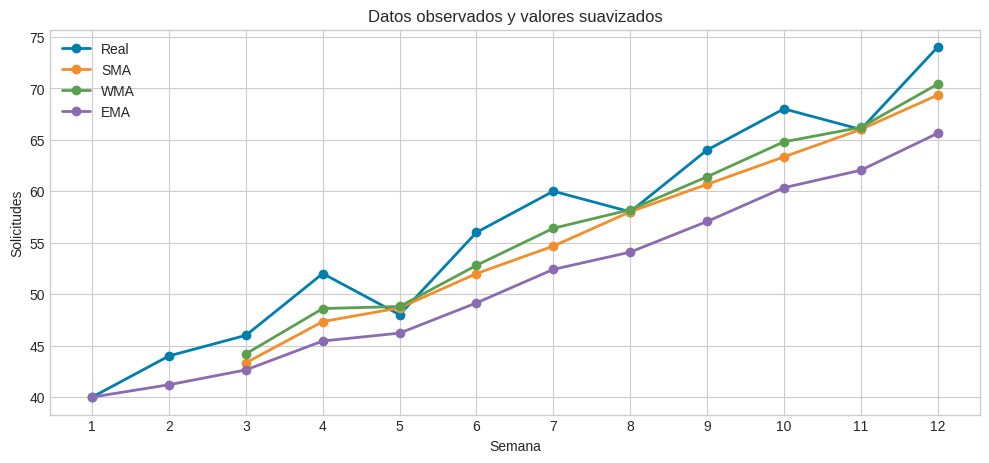

In [ ]:
colores = {"Real": "#007FAF", "SMA": "#F28E2B", "WMA": "#59A14F", "EMA": "#8B6BB1"}
ax = suavizados.plot(
    figsize=(12, 5), marker="o", linewidth=2,
    color=[colores[columna] for columna in suavizados.columns]
)
ax.set(title="Datos observados y valores suavizados", xlabel="Semana", ylabel="Solicitudes")
ax.set_xticks(serie.index)
plt.show()


### Pregunta 2. Interpretar el suavizado

1. ¿Qué información se pierde y qué información se vuelve más visible al suavizar?
2. Entre SMA y WMA, ¿cuál responde más a la semana reciente? Relacione su respuesta con los pesos.
3. ¿Por qué la línea naranja de SMA empieza en la semana 3?
4. Explique por qué esta gráfica todavía no demuestra cuál método pronostica mejor.

**Respuesta:**  
1. Se pierde la información de la fluctuación real, ya que los picos se suavizan y tenemos un movimiento más homogéneo. Sin embargo, es más visible el comportamiento general, que en este caso es de aumento.
2. El WMA responde mejor a la semana más reciente debido a que en el SMA los pesos son los mismos para las 3 semanas que estamos considerando para evaluar el promedio, cada uno es de 1/3, en el caso de la WMA, la semana más reciente tiene mayor peso, de 0.5 y desciende hacia la semana más lejana.
3. Porque se seleccionó una media móvil de tamaño k = 3, con lo que se necesitan 3 observaciones para realizar el cálculo, así que solo tiene datos de 3 semanas cuando empieza la tercera.
4. La gráfica nos muestra valores suavizados, no pronósticos. Estos valores suavizados son promedios, que toman en cuenta a la semana que estamos promediando. Por ejemplo, la semana 3 usa el valor de la semana 3, así que no puede pronosticar con un dato que ya conoce. El pronóstico se realiza hacia el futuro, sobre datos que no conocemos.


## 5. Después: convertir el suavizado en pronóstico

Para pronosticar la semana $t$, el dato real de esa semana aún no existe. El cálculo solamente puede usar información conocida hasta $t-1$.

La diferencia se aprecia en la semana 4:

- **SMA suavizado de la semana 4:** promedia las semanas 2, 3 y 4; incluye el valor 52 de la propia semana 4.
- **Pronóstico SMA para la semana 4:** promedia las semanas 1, 2 y 3; no utiliza el valor 52 que intenta anticipar.

En el código, `.shift(1)` mueve los valores suavizados una semana hacia la derecha para convertirlos en pronósticos de un paso adelante.


In [ ]:
pronosticos = pd.DataFrame({"Real": serie})
pronosticos["SMA"] = suavizados["SMA"].shift(1)
pronosticos["WMA"] = suavizados["WMA"].shift(1)
pronosticos["EMA"] = suavizados["EMA"].shift(1)

# Baseline ingenuo: repetir el último dato observado
pronosticos["Ingenuo"] = serie.shift(1)

# Baseline estacional de periodo 2: repetir el dato de dos periodos atrás
pronosticos["Estacional_2"] = serie.shift(2)

display(pronosticos.round(3))

,Real,SMA,WMA,EMA,Ingenuo,Estacional_2
Semana,,,,,,
1,40,NaN,NaN,NaN,NaN,NaN
2,44,NaN,NaN,40.000,40.000,NaN
3,46,NaN,NaN,41.200,44.000,40.000
4,52,43.333,44.200,42.640,46.000,44.000
5,48,47.333,48.600,45.448,52.000,46.000
6,56,48.667,48.800,46.214,48.000,52.000
7,60,52.000,52.800,49.150,56.000,48.000
8,58,54.667,56.400,52.405,60.000,56.000
9,64,58.000,58.200,54.083,58.000,60.000


### Comprobación del pronóstico para la semana 4

El pronóstico SMA usa únicamente las semanas 1, 2 y 3:

$$
\widehat y_{4|3}=\frac{40+44+46}{3}=43.33
$$

El dato observado de la semana 4 fue 52. Por tanto, el error del pronóstico SMA es $52-43.33=8.67$ solicitudes. El error solo puede calcularse después de conocer el valor real.


,Real,SMA,WMA,EMA,Ingenuo,Estacional_2
Semana,,,,,,
3,46,NaN,NaN,41.200,44.000,40.000
4,52,43.333,44.200,42.640,46.000,44.000
5,48,47.333,48.600,45.448,52.000,46.000


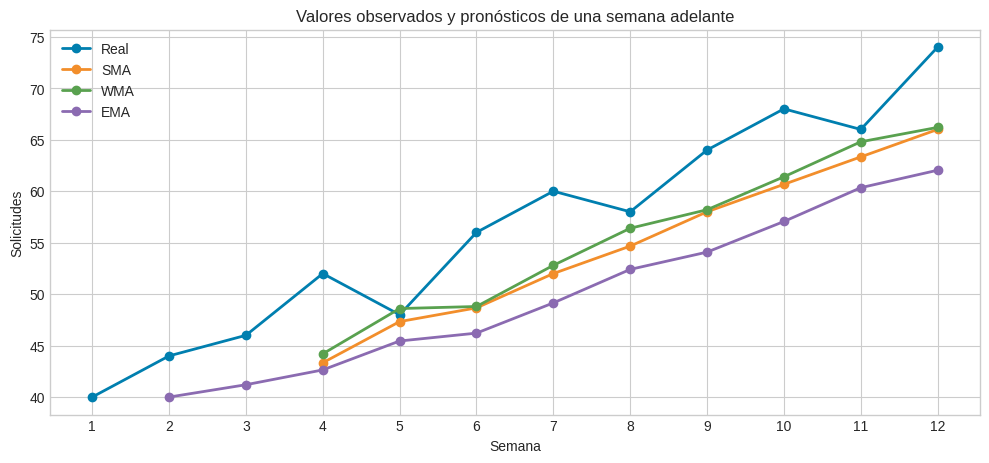

In [ ]:
display(pronosticos.loc[[3, 4, 5]].round(3))

ax = pronosticos[["Real", "SMA", "WMA", "EMA"]].plot(
    figsize=(12, 5), marker="o", linewidth=2,
    color=["#007FAF", "#F28E2B", "#59A14F", "#8B6BB1"]
)
ax.set(title="Valores observados y pronósticos de una semana adelante",
       xlabel="Semana", ylabel="Solicitudes")
ax.set_xticks(serie.index)
plt.show()


## 6. Comparación justa mediante métricas

No basta con observar qué línea parece más cercana. Compararemos todos los métodos solamente en las semanas donde **todos** tienen un pronóstico disponible.

- **MAE:** distancia absoluta promedio entre lo observado y lo pronosticado. Se expresa en solicitudes y es fácil de interpretar.
- **RMSE:** también se expresa en solicitudes, pero aumenta más cuando existen errores grandes.
- **sMAPE:** expresa el error relativo en porcentaje y trata de forma simétrica observados y pronósticos.

Como referencia incluiremos dos métodos simples:

- **Ingenuo:** pronostica que la siguiente semana será igual a la última observada.
- **Estacional de periodo 2:** repite el valor observado dos semanas antes. Aquí es una referencia didáctica; no afirmamos todavía que exista estacionalidad real.


In [ ]:
def calcular_metricas(real, predicho):
    real = np.asarray(real, dtype=float)
    predicho = np.asarray(predicho, dtype=float)

    mae = np.mean(np.abs(real - predicho))
    rmse = np.sqrt(np.mean((real - predicho) ** 2))

    denominador = np.abs(real) + np.abs(predicho)
    smape = np.mean(
        np.where(denominador == 0, 0, 2 * np.abs(real - predicho) / denominador)
    ) * 100

    return {"MAE": mae, "RMSE": rmse, "sMAPE": smape}


def evaluar_en_ventana_comun(tabla, metodos):
    mascara_comun = tabla[["Real"] + metodos].notna().all(axis=1)
    evaluacion = tabla.loc[mascara_comun]

    resultados = {
        metodo: calcular_metricas(evaluacion["Real"], evaluacion[metodo])
        for metodo in metodos
    }

    return pd.DataFrame(resultados).T.sort_values("RMSE"), evaluacion

In [ ]:
metodos = ["SMA", "WMA", "EMA", "Ingenuo", "Estacional_2"]
metricas_serie, ventana_comun = evaluar_en_ventana_comun(pronosticos, metodos)

print("Primera semana de la ventana común:", ventana_comun.index.min())
print("Número de pronósticos comparados:", len(ventana_comun))
display(metricas_serie.round(3))

# Pronósticos para la semana 13. Todavía no se conoce su valor real.
pronostico_semana_13 = pd.Series({
    "SMA": serie.iloc[-k:].mean(),
    "WMA": np.dot(serie.iloc[-len(pesos):], pesos),
    "EMA": suavizados.loc[12, "EMA"],
    "Ingenuo": serie.loc[12],
    "Estacional_2": serie.loc[11],
}, name="Pronóstico semana 13")

print("\nPronósticos disponibles para planear la semana 13:")
display(pronostico_semana_13.to_frame().round(3))


Primera semana de la ventana común: 4
Número de pronósticos comparados: 9


,MAE,RMSE,sMAPE
Ingenuo,4.889,5.333,8.470
WMA,5.089,5.840,8.824
SMA,5.778,6.371,10.065
Estacional_2,5.556,6.566,9.768
EMA,8.514,9.019,15.028



Pronósticos disponibles para planear la semana 13:


,Pronóstico semana 13
SMA,69.333
WMA,70.400
EMA,65.627
Ingenuo,74.000
Estacional_2,66.000


### Pregunta 3. Del resultado a una decisión

1. ¿Qué método obtiene el menor RMSE en la ventana común?
2. ¿Alguno de los métodos de suavizado supera al pronóstico ingenuo?
3. ¿Qué muestran los resultados sobre el retraso de SMA, WMA y EMA cuando la serie aumenta?
4. Si tuviera que planear personal para la semana 13, ¿qué pronóstico usaría y qué precaución comunicaría a la administración?

**Respuesta:**  
1. El método ingenuo con 5.333 con una diferencia casi de 4 respecto al mayor, que tiene 9.019.
2. Ninguno supera el pronóstico ingenuo, tiene el menor MAE, RMSE y sMAPE.
3. A medida que la serie tiene tendencia creciente, la diferencia entre el valor real y los pronósticos de SMA, WWMA y EMA también aumenta, debido a que usan valores pasados. El EMA es el que más retrasa este caso. EL WMA asigna más peso a la semana más reciente, así que reacciona un poco mejor.
4. El pronóstico ingenuo es el mejor y se debe considerar el error común de 5 solicitudes. También aclararía que es un pronóstico y que debe tomarse en cuenta factores externos y la opinión de expertos en el área.


## 7. Una comprobación importante: no existe un ganador universal

La serie de solicitudes nos permitió aprender el procedimiento. Ahora aplicaremos exactamente los mismos métodos a cuatro series construidas con estructuras distintas.

El objetivo no es buscar un algoritmo que gane siempre, sino explicar **por qué** un método funciona mejor o peor dependiendo de si los datos muestran nivel estable, tendencia o un patrón repetitivo.


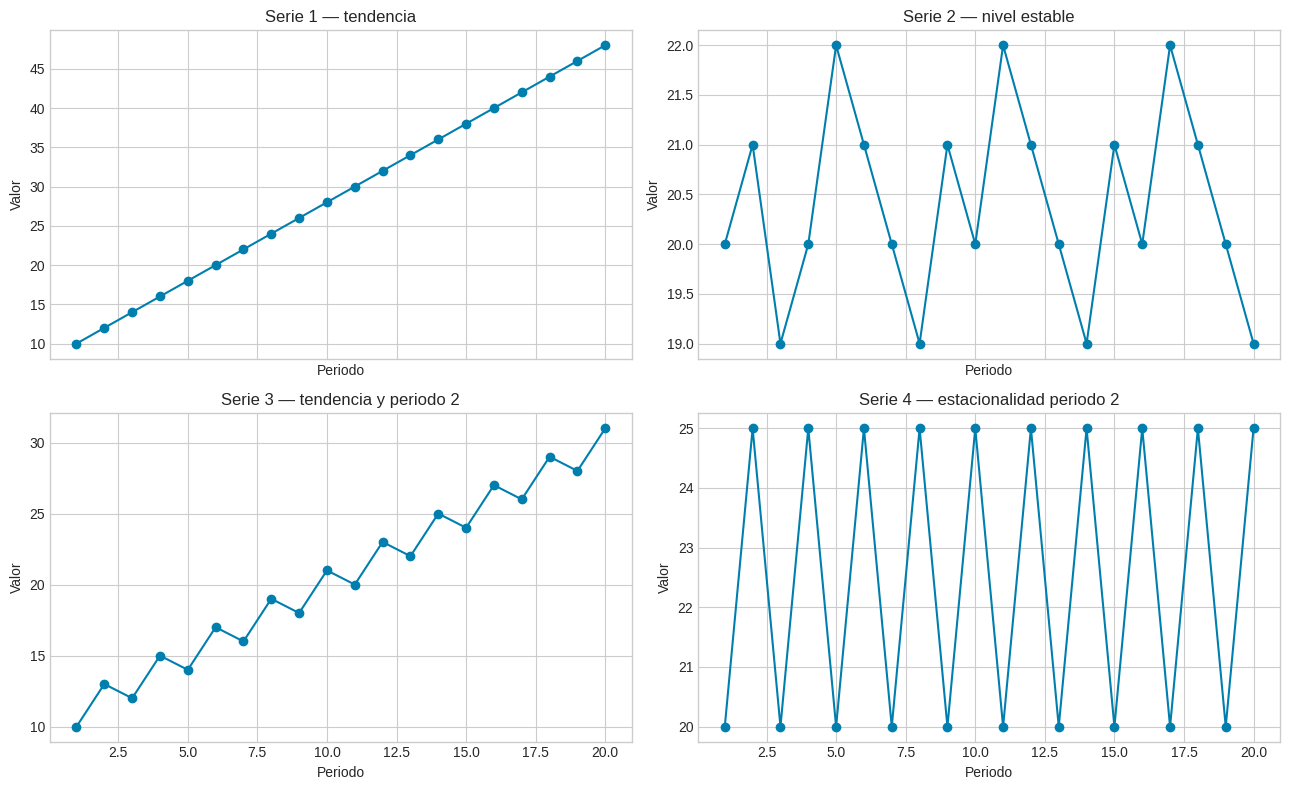

In [ ]:
series = {
    "Serie 1 — tendencia": [10, 12, 14, 16, 18, 20, 22, 24, 26, 28,
                             30, 32, 34, 36, 38, 40, 42, 44, 46, 48],
    "Serie 2 — nivel estable": [20, 21, 19, 20, 22, 21, 20, 19, 21, 20,
                                 22, 21, 20, 19, 21, 20, 22, 21, 20, 19],
    "Serie 3 — tendencia y periodo 2": [10, 13, 12, 15, 14, 17, 16, 19, 18, 21,
                                         20, 23, 22, 25, 24, 27, 26, 29, 28, 31],
    "Serie 4 — estacionalidad periodo 2": [20, 25, 20, 25, 20, 25, 20, 25, 20, 25,
                                            20, 25, 20, 25, 20, 25, 20, 25, 20, 25],
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, (nombre, valores) in zip(axes.ravel(), series.items()):
    ax.plot(range(1, 21), valores, marker="o", color="#007FAF")
    ax.set_title(nombre)
    ax.set_xlabel("Periodo")
    ax.set_ylabel("Valor")
plt.tight_layout()
plt.show()

### Pregunta 4. Reconocer la estructura antes de ver las métricas

Para cada serie, describa con palabras sencillas qué observa: ¿sube o baja?, ¿permanece alrededor de un nivel?, ¿alterna valores?, ¿repite un patrón?

Después formule una hipótesis: ¿qué tipo de pronóstico podría tener ventaja en cada caso?

**Respuesta:**  
* Serie 1. Sube de forma constante y sin reportar cambios de dirección. El pronóstico ingenuo tiene ventaja porque se usa el valor del último periodo. Sin embargo, no es infalible, porque como aumenta 2 unidades cada periodo siempre tendrá ese error (2).
* Serie 2. Tiene tendencia a permanecer en un nivel, sube y baja, pero sin mantener un patrón estacional. Los métodos que se obtienen con media móvil podrían funcionar bien en este caso.
* Serie 3. Tiene tendencia a subir, baja y sube por patrones.Un modelo estacional cada 2 periodos dará un buen pronóstico ya que los valores suben y bajan de forma periódica con valores similares.
* Serie 4. Tiene tendencia a permanecer en un nivel, sube y baja, manteniendo su nivel arriba y abajo. Un modelo estacional dará un buen pronóstico ya que los valores suben y bajan de forma periódica con valores similares.


In [ ]:
def construir_pronosticos(valores, k=3, pesos=np.array([0.2, 0.3, 0.5]), alpha=0.3):
    y = pd.Series(valores, index=np.arange(1, len(valores) + 1), dtype=float)
    tabla = pd.DataFrame({"Real": y})

    sma = y.rolling(k).mean()
    wma = y.rolling(len(pesos)).apply(lambda ventana: np.dot(ventana, pesos), raw=True)
    ema = y.ewm(alpha=alpha, adjust=False).mean()

    tabla["SMA"] = sma.shift(1)
    tabla["WMA"] = wma.shift(1)
    tabla["EMA"] = ema.shift(1)
    tabla["Ingenuo"] = y.shift(1)
    tabla["Estacional_2"] = y.shift(2)
    return tabla


resumen = []
tablas = {}

for nombre, valores in series.items():
    tabla = construir_pronosticos(valores, k=k, pesos=pesos, alpha=alpha)
    metricas, evaluacion = evaluar_en_ventana_comun(tabla, metodos)
    tablas[nombre] = tabla

    for metodo, fila in metricas.iterrows():
        resumen.append({"Serie": nombre, "Método": metodo, **fila.to_dict()})

resumen_metricas = pd.DataFrame(resumen)
tabla_rmse = resumen_metricas.pivot(index="Serie", columns="Método", values="RMSE")
display(tabla_rmse.round(3))

Método,EMA,Estacional_2,Ingenuo,SMA,WMA
Serie,,,,,
Serie 1 — tendencia,6.252,4.000,2.000,4.000,3.400
Serie 2 — nivel estable,1.133,1.590,1.372,1.316,1.273
Serie 3 — tendencia y periodo 2,3.463,2.000,2.288,2.468,2.265
Serie 4 — estacionalidad periodo 2,2.996,0.000,5.000,3.333,3.500


In [ ]:
ganadores = (
    resumen_metricas.loc[resumen_metricas.groupby("Serie")["RMSE"].idxmin(),
                         ["Serie", "Método", "RMSE"]]
    .sort_values("Serie")
)
display(ganadores.round(3))

,Serie,Método,RMSE
0,Serie 1 — tendencia,Ingenuo,2.000
5,Serie 2 — nivel estable,EMA,1.133
10,Serie 3 — tendencia y periodo 2,Estacional_2,2.000
15,Serie 4 — estacionalidad periodo 2,Estacional_2,0.000


### Pregunta 5. Explicar por qué cambia el ganador

Complete la tabla:

| Serie | Método con menor RMSE | Evidencia visible en la serie | Explicación |
|---|---|---|---|
| 1 | Ingenuo, RMSE = 2.000 | Sí, sube linealmente y no tiene cambios de dirección | La serie aumenta de forma gradual y uniforme sin cambiar dirección, así que tomar el valor anterior tiene un error constante de 2 solicitudes, que supera a los promedios. |
| 2 | EMA, RMSE = 1.133 | No hay una tendencia clara, ni estacionalidad. Los valores oscilan entre 20 y 21. | El Ema con $\alpha$ = 0.3 adapta bien las variaciones y estima mejor que el ingenuo o el estacional |
| 3 | Estacional_2, RMSE = 2.000 | Sí, toma en cuenta las subidas y bajadas cda dos periodos, que aumentan de forma general | Los patrones de aumento y descenso son visibles y uniformes por patrones estacionales, por lo que es el mejor modelo|
| 4 | Estacional_2, RMSE = 0.000 | Sí, se alternan perfectamente | Los patrones de aumento y descenso son visibles y uniformes por patrones estacionales, así que no tiene error |

¿En cuáles series SMA, WMA o EMA fueron superados por un método de referencia? Explique qué estructura aprovechó ese método.

En la serie 1, 3 y 4, las estructuras con tendencia constante creciente aprovechan estos métodos porque el ingenuo o el estacional pueden pronosticar al tomar los valores más cercanos.

## 8. Selección de $\alpha$ sin mirar el futuro

Usaremos la **Serie 2**, cuyo nivel es relativamente estable. Probaremos varios valores de $\alpha$ en los periodos 13–16, que funcionarán como validación. Después evaluaremos una sola vez en los periodos 17–20, reservados como prueba final.

La regla es sencilla: una decisión sobre el parámetro debe tomarse con datos anteriores al periodo que se usará para reportar el desempeño final. De lo contrario, estaríamos usando indirectamente información del futuro.


Mejor α en validación: 0.05


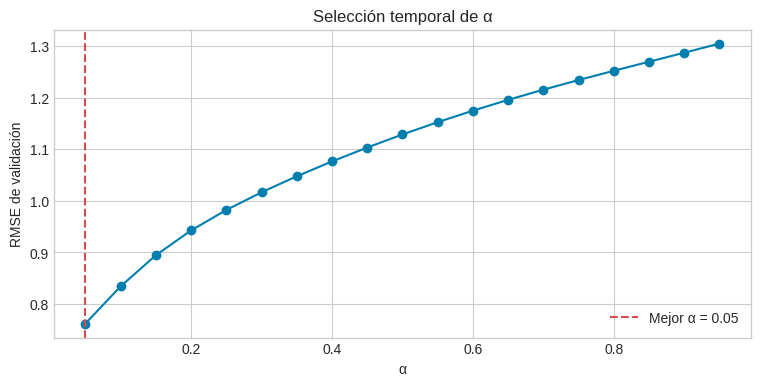

In [ ]:
y_alpha = pd.Series(series["Serie 2 — nivel estable"], index=np.arange(1, 21), dtype=float)
alphas = np.arange(0.05, 1.00, 0.05)
errores_validacion = []

for candidato in alphas:
    pronostico = y_alpha.ewm(alpha=candidato, adjust=False).mean().shift(1)
    real_val = y_alpha.loc[13:16]
    pred_val = pronostico.loc[13:16]
    rmse_val = calcular_metricas(real_val, pred_val)["RMSE"]
    errores_validacion.append(rmse_val)

mejor_alpha = float(alphas[np.argmin(errores_validacion)])
print(f"Mejor α en validación: {mejor_alpha:.2f}")

plt.figure(figsize=(9, 4))
plt.plot(alphas, errores_validacion, marker="o", color="#007FAF")
plt.axvline(mejor_alpha, color="#D64B4B", linestyle="--", label=f"Mejor α = {mejor_alpha:.2f}")
plt.xlabel("α")
plt.ylabel("RMSE de validación")
plt.title("Selección temporal de α")
plt.legend()
plt.show()

In [ ]:
pronostico_final = y_alpha.ewm(alpha=mejor_alpha, adjust=False).mean().shift(1)
metricas_prueba = calcular_metricas(y_alpha.loc[17:20], pronostico_final.loc[17:20])

print("Métricas en prueba final (periodos 17–20):")
display(pd.DataFrame([metricas_prueba], index=[f"EMA α={mejor_alpha:.2f}"]).round(3))

Métricas en prueba final (periodos 17–20):


,MAE,RMSE,sMAPE
EMA α=0.05,1.036,1.178,5.059


### Pregunta 6. Interpretar $\alpha$

1. ¿Qué valor de $\alpha$ fue seleccionado?
2. ¿Ese valor da mayor importancia al dato reciente o a la memoria acumulada?
3. ¿Por qué es razonable en una serie que oscila alrededor de un nivel estable?
4. ¿Qué problema surgiría si eligiéramos $\alpha$ utilizando los periodos de prueba final?

**Respuesta:**  
1. El valor de $\alpha$ fue 0.05
2. El valor que utilizamos es pequeño y da más importancia a la memoria acumulada. El 0.05 hace referencia al 5%, por lo que el otro 95% toma en cuenta el nivel anterior.
3. La serie 2 oscila en un nivel, pero no tiene tendencia, ni estacionalidad clara. El $\alpha$ pequeño hace que no se tomen en cuenta tanto las subidas y bajadas tan marcadas, porque suaviza el ruido.
4. Que estaríamos rompiendo la regla de usar parámetros anteriores para realizar pronósticos futuros.


## 9. Conclusión general

Redacte entre **150 y 250 palabras**. Su conclusión debe responder, con sus propias palabras:

- ¿Cuál es la diferencia entre suavizar y pronosticar?
- ¿Cómo cambian la reacción del método la ventana $k$, los pesos y $\alpha$?
- ¿Por qué no hubo un solo método ganador para todas las series?
- ¿Qué método de referencia superó a los suavizados en algún caso y por qué?
- ¿Qué revisaría antes de utilizar un pronóstico para tomar una decisión real?

### Conclusión

Después de haber trabajado con datos ficticios y comparar los métodos ingenuo, estacional, SMA, WMA y EMA, me queda claro que no existe un método ideal para todas las series. Los métodos SMA, WMA y EMA sirven para suavizar una serie temporal, es decir, usan los datos conocidos para mostrar una versión más estable y así podemos observar mejor la tendencia o el nivel general. En contraste, un pronóstico utiliza únicamente información pasada para anticipar el futuro, el dato que se quiere predecir todavía no se conoce. La reacción de estos métodos depende de sus parámetros: (i) una ventana $k$ más grande suaviza más y reacciona más lento, (ii) unos pesos que dan más importancia a la semana reciente hacen al método más sensible a los últimos cambios, (iii) un $\alpha$ alto en el EMA también responde más rápido al dato nuevo y (iv)un $\alpha$ bajo conserva más memoria.
No hubo un ganador único porque cada serie tenía una estructura distinta, tendencia, nivel estable o estacionalidad de periodo 2. En varias series, los métodos de referencia superaron a los suavizados y el ingenuo fue mejor en tendencia pura y el estacional_2 fue superior cuando existía un patrón repetitivo de dos periodos. Antes de usar un pronóstico en una decisión real, compararía los errores en una ventana de validación (RME, RMSE, sMAPE), evitaría ajustar parámetros con datos futuros y consideraría la incertidumbre del pronóstico, complementándolo con la opinión de expertos.




## 10. Lista de verificación antes de entregar

- ✔️ Ejecuté todas las celdas sin errores.
- ✔️ Expliqué la estructura inicial de la serie de solicitudes.
- ✔️ Distinguí el SMA suavizado de la semana 4 del pronóstico SMA para esa semana.
- ✔️ Interpreté las gráficas y no solo copié los valores de las tablas.
- ✔️ Respondí las seis preguntas de análisis.
- ✔️ Completé la tabla de interpretación por serie.
- ✔️ Redacté la conclusión de 150 a 250 palabras.
- ✔️ Guardé el notebook con mi nombre en el archivo.
